# 1. Importación de librerías y datos

In [33]:
import pandas as pd 
import numpy as np 
import os
import matplotlib.pyplot as plt

In [34]:
ruta = r"C:\Users\Samuel\Desktop\Proyectos\E-Commerce Sales Analytics Dataset"

In [35]:
os.listdir(ruta)

['customer_master.csv',
 'Data',
 'Dataset de análisis de ventas de comercio electrónico.docx',
 'ecommerce_sales_customer_analytics_150k.csv',
 'Media',
 'Notebooks',
 'order_items.csv',
 'product_catalog.csv']

In [36]:
clientes = pd.read_csv(
    os.path.join(ruta, "customer_master.csv")
)

productos = pd.read_csv(
    os.path.join(ruta, "product_catalog.csv")
    
)

pedidos =  pd.read_csv(
    os.path.join(ruta, "order_items.csv")
)

ventas = pd.read_csv(
    os.path.join(ruta, "ecommerce_sales_customer_analytics_150k.csv")
)

In [37]:
print(clientes.shape)
print(productos.shape)
print(pedidos.shape)
print(ventas.shape)

(25000, 11)
(1175, 9)
(397569, 12)
(138116, 46)


# 2. Limpieza de los datos por categoría. 

### Tabla de clientes

In [38]:
clientes.head()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [39]:
clientes.shape
clientes.info()
clientes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  object 
 1   customer_name              25000 non-null  object 
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  object 
 4   customer_segment           25000 non-null  object 
 5   customer_city              25000 non-null  object 
 6   customer_state             25000 non-null  object 
 7   customer_country           25000 non-null  object 
 8   region                     25000 non-null  object 
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


,customer_age,customer_postal_code,customer_acquisition_cost
count,25000.000000,25000.000000,25000.000000
mean,45.907840,50183.066400,42.159750
std,16.454286,28596.584321,21.692648
min,18.000000,516.000000,5.010000
25%,32.000000,25374.500000,23.297500
50%,46.000000,50303.000000,41.980000
75%,60.000000,74845.500000,61.130000
max,74.000000,99950.000000,79.990000


In [40]:
clientes.columns.tolist()

['customer_id',
 'customer_name',
 'customer_age',
 'gender',
 'customer_segment',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'customer_postal_code',
 'customer_acquisition_cost']

In [41]:
clientes.duplicated().sum()

0

In [42]:
clientes[clientes.duplicated(keep=False)]

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost


In [43]:
clientes.isnull().sum()

customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_postal_code         0
customer_acquisition_cost    0
dtype: int64

In [44]:
clientes.dtypes

customer_id                   object
customer_name                 object
customer_age                   int64
gender                        object
customer_segment              object
customer_city                 object
customer_state                object
customer_country              object
region                        object
customer_postal_code           int64
customer_acquisition_cost    float64
dtype: object

In [45]:
columnas_texto = [
    "customer_id",
    "customer_name",
    "gender",
    "customer_segment",
    "customer_city",
    "customer_state",
    "customer_country",
    "region",
    "customer_postal_code"
]

for col in columnas_texto: 
    clientes[col] = clientes[col].astype("string")

In [46]:
clientes.dtypes

customer_id                   string
customer_name                 string
customer_age                   int64
gender                        string
customer_segment              string
customer_city                 string
customer_state                string
customer_country              string
region                        string
customer_postal_code          string
customer_acquisition_cost    float64
dtype: object

In [47]:
clientes = clientes.rename(columns ={
     "customer_id": "id_cliente",
    "customer_name": "nombre_cliente",
    "customer_age": "edad_cliente",
    "gender": "genero",
    "customer_segment": "segmento_cliente",
    "customer_city": "ciudad_cliente",
    "customer_state": "estado_cliente",
    "customer_country": "pais_cliente",
    "region": "region",
    "customer_postal_code": "codigo_postal_cliente",
    "customer_acquisition_cost": "coste_adquisicion_cliente"
    
})

In [48]:
clientes.columns.to_list()

['id_cliente',
 'nombre_cliente',
 'edad_cliente',
 'genero',
 'segmento_cliente',
 'ciudad_cliente',
 'estado_cliente',
 'pais_cliente',
 'region',
 'codigo_postal_cliente',
 'coste_adquisicion_cliente']

In [119]:
# ==============================
# COMPROBACIÓN FINAL - CLIENTES
# ==============================

print("FORMA DEL DATASET")
print(clientes.shape)

print("\nTIPOS DE DATOS")
print(clientes.dtypes)

print("\nVALORES NULOS")
print(clientes.isnull().sum())

print("\nDUPLICADOS COMPLETOS")
print(clientes.duplicated().sum())

print("\nID_CLIENTE DUPLICADOS")
print(clientes["id_cliente"].duplicated().sum())

print("\nID_CLIENTE NULOS")
print(clientes["id_cliente"].isnull().sum())

print("\nEDAD")
print(clientes["edad_cliente"].describe())

print("\nEDADES FUERA DE RANGO 18-100")
print(
    (
        (clientes["edad_cliente"] < 18) |
        (clientes["edad_cliente"] > 100)
    ).sum()
)

print("\nGÉNERO")
print(clientes["genero"].value_counts(dropna=False))

print("\nSEGMENTOS")
print(clientes["segmento_cliente"].value_counts(dropna=False))

print("\nCIUDADES")
print(clientes["ciudad_cliente"].value_counts(dropna=False).head(20))

print("\nESTADOS")
print(clientes["estado_cliente"].value_counts(dropna=False).head(20))

print("\nPAÍSES")
print(clientes["pais_cliente"].value_counts(dropna=False))

print("\nREGIONES")
print(clientes["region"].value_counts(dropna=False))

print("\nCÓDIGOS POSTALES NULOS")
print(clientes["codigo_postal_cliente"].isnull().sum())

print("\nCOSTE DE ADQUISICIÓN")
print(clientes["coste_adquisicion_cliente"].describe())

print("\nCOSTES DE ADQUISICIÓN NEGATIVOS")
print(
    (clientes["coste_adquisicion_cliente"] < 0).sum()
)

print("\nPRIMERAS FILAS")
display(clientes.head())

FORMA DEL DATASET
(25000, 11)

TIPOS DE DATOS
id_cliente                    string
nombre_cliente                string
edad_cliente                   int64
genero                        string
segmento_cliente              string
ciudad_cliente                string
estado_cliente                string
pais_cliente                  string
region                        string
codigo_postal_cliente         string
coste_adquisicion_cliente    float64
dtype: object

VALORES NULOS
id_cliente                   0
nombre_cliente               0
edad_cliente                 0
genero                       0
segmento_cliente             0
ciudad_cliente               0
estado_cliente               0
pais_cliente                 0
region                       0
codigo_postal_cliente        0
coste_adquisicion_cliente    0
dtype: int64

DUPLICADOS COMPLETOS
0

ID_CLIENTE DUPLICADOS
0

ID_CLIENTE NULOS
0

EDAD
count    25000.000000
mean        45.907840
std         16.454286
min         18.000000
2

,id_cliente,nombre_cliente,edad_cliente,genero,segmento_cliente,ciudad_cliente,estado_cliente,pais_cliente,region,codigo_postal_cliente,coste_adquisicion_cliente
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


### Tabla de productos

In [50]:
productos.head()

,product_id,product_name,product_category,product_subcategory,brand,supplier,unit_price,product_cost,product_rating
0,PROD-000001,Apple Sharable bifurcated algorithm Smartphones,Electronics,Smartphones,Apple,Alibaba,686.90,474.06,4.3
1,PROD-000002,Google User-centric even-keeled encryption Sma...,Electronics,Smartphones,Google,Euro Logistics,978.26,519.66,2.9
2,PROD-000003,LG Face-to-face client-driven support Smartphones,Electronics,Smartphones,LG,Asian Manufacturing,275.51,185.48,3.9
3,PROD-000004,Sony Customer-focused systematic support Smart...,Electronics,Smartphones,Sony,Amazon Supply,1120.49,564.86,4.8
4,PROD-000005,OnePlus Quality-focused background parallelism...,Electronics,Smartphones,OnePlus,Direct Import,1282.18,695.54,2.9


In [51]:
productos.shape

(1175, 9)

In [52]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1175 non-null   object 
 1   product_name         1175 non-null   object 
 2   product_category     1175 non-null   object 
 3   product_subcategory  1175 non-null   object 
 4   brand                1175 non-null   object 
 5   supplier             1175 non-null   object 
 6   unit_price           1175 non-null   float64
 7   product_cost         1175 non-null   float64
 8   product_rating       1175 non-null   float64
dtypes: float64(3), object(6)
memory usage: 82.7+ KB


In [53]:
productos.describe()
#Tanto en precio unitario como en el coste del producto podemos observar que la media está por encima de la mediana. 
#Realizamos comprobaciones.

,unit_price,product_cost,product_rating
count,1175.000000,1175.000000,1175.000000
mean,245.524400,126.536826,3.683064
std,251.267683,150.131833,0.698046
min,6.310000,1.970000,2.500000
25%,74.710000,29.565000,3.100000
50%,165.420000,74.540000,3.700000
75%,311.295000,153.045000,4.300000
max,1482.950000,993.630000,4.900000


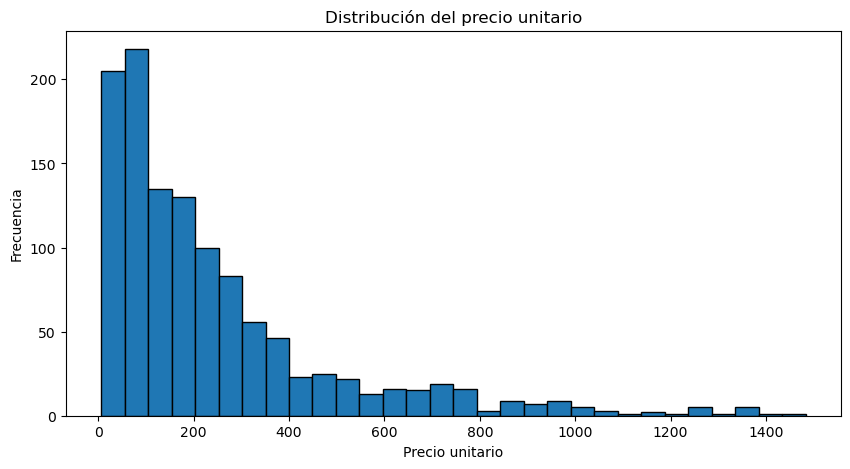

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(productos["unit_price"], bins=30, edgecolor="black")

plt.title("Distribución del precio unitario")
plt.xlabel("Precio unitario")
plt.ylabel("Frecuencia")

plt.show()

Este histograma nos muestra una desviación clara hacia la derecha, es decir, la mayoría de los productos tienen un precio unitario que va desde los 0 euros hasta los 300. Además la frecuencia más alta está entre los 0 y los 100 euros. A medida que sube el precio unitario (1400-1500 euros) vemos como la frecuencia baja drásticamente.

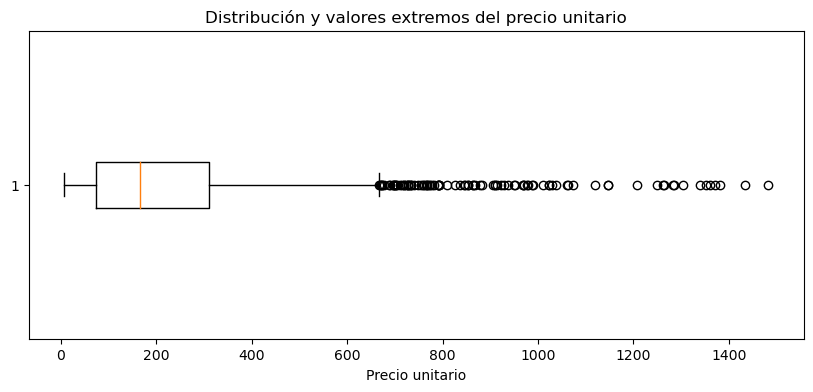

In [55]:
plt.figure(figsize=(10, 4))

plt.boxplot(productos["unit_price"], vert=False)

plt.title("Distribución y valores extremos del precio unitario")
plt.xlabel("Precio unitario")

plt.show()

El gráfico de caja y bigotes, por su parte, nos marca muchos valores como outliers a partir de los 650 euros aproximadamente. La mediana (línea naranja) se ubica entorno a los 170 euros y la media va desde los 70 euros hasta los 310 euros confirmando así los datos del histograma. 

In [56]:
#¿Qué producots y cuántos están por encima de los límites?

limite_superior = 670
outliers_precio = productos [
    productos["unit_price"] > limite_superior
].sort_values("unit_price", ascending = False)

print("Número de productos:", len(outliers_precio))
print("Porcentaje:", len(outliers_precio) / len(productos) * 100)

Número de productos: 94
Porcentaje: 8.0


Se identificaron 94 productos con precios altos, equivalentes al 8% del catálogo. Tras analizar la distribución, estos valores se mantienen, ya que representan productos de mayor precio dentro del catálogo y no existen indicios suficientes para considerarlos errores o anomalías.

In [57]:
productos.columns.to_list()

['product_id',
 'product_name',
 'product_category',
 'product_subcategory',
 'brand',
 'supplier',
 'unit_price',
 'product_cost',
 'product_rating']

In [58]:
productos.duplicated().sum()

0

In [59]:
productos[productos.duplicated(keep=False)]

,product_id,product_name,product_category,product_subcategory,brand,supplier,unit_price,product_cost,product_rating


In [60]:
productos.isnull().sum()

product_id             0
product_name           0
product_category       0
product_subcategory    0
brand                  0
supplier               0
unit_price             0
product_cost           0
product_rating         0
dtype: int64

In [61]:
productos.columns.to_list()

['product_id',
 'product_name',
 'product_category',
 'product_subcategory',
 'brand',
 'supplier',
 'unit_price',
 'product_cost',
 'product_rating']

In [62]:
columnas = [
    'product_id',
 'product_name',
 'product_category',
 'product_subcategory',
 'brand',
 'supplier'
    
]

for col in columnas: 
    productos[col] = productos [col].astype("object")

In [63]:
productos.dtypes

product_id              object
product_name            object
product_category        object
product_subcategory     object
brand                   object
supplier                object
unit_price             float64
product_cost           float64
product_rating         float64
dtype: object

In [64]:
columnas_texto = [
    'product_id',
     'product_name',
     'product_category',
     'product_subcategory',
     'brand',
     'supplier'
    
]

for col in columnas_texto: 
    productos[col] = productos [col].astype("string")

In [65]:
productos.dtypes

product_id              string
product_name            string
product_category        string
product_subcategory     string
brand                   string
supplier                string
unit_price             float64
product_cost           float64
product_rating         float64
dtype: object

In [66]:
productos = productos.rename(columns={
    "product_id": "id_producto",
    "product_name": "nombre_producto",
    "product_category": "categoria_producto",
    "product_subcategory": "subcategoria_producto",
    "brand": "marca",
    "supplier": "proveedor",
    "unit_price": "precio_unitario",
    "product_cost": "coste_producto",
    "product_rating": "valoracion_producto"
})

In [67]:
productos.columns.to_list()

['id_producto',
 'nombre_producto',
 'categoria_producto',
 'subcategoria_producto',
 'marca',
 'proveedor',
 'precio_unitario',
 'coste_producto',
 'valoracion_producto']

In [120]:
# ==============================
# COMPROBACIÓN FINAL - PRODUCTOS
# ==============================

print("FORMA DEL DATASET")
print(productos.shape)

print("\nTIPOS DE DATOS")
print(productos.dtypes)

print("\nVALORES NULOS")
print(productos.isnull().sum())

print("\nDUPLICADOS COMPLETOS")
print(productos.duplicated().sum())

print("\nID_PRODUCTO DUPLICADOS")
print(productos["id_producto"].duplicated().sum())

print("\nID_PRODUCTO NULOS")
print(productos["id_producto"].isnull().sum())

print("\nCATEGORÍAS")
print(productos["categoria_producto"].value_counts(dropna=False))

print("\nSUBCATEGORÍAS")
print(productos["subcategoria_producto"].value_counts(dropna=False))

print("\nMARCAS")
print(productos["marca"].value_counts(dropna=False))

print("\nPROVEEDORES")
print(productos["proveedor"].value_counts(dropna=False))

print("\nPRECIO UNITARIO")
print(productos["precio_unitario"].describe())

print("\nCOSTE PRODUCTO")
print(productos["coste_producto"].describe())

print("\nVALORACIÓN PRODUCTO")
print(productos["valoracion_producto"].describe())

print("\nPRECIOS <= 0")
print(
    (productos["precio_unitario"] <= 0).sum()
)

print("\nCOSTES < 0")
print(
    (productos["coste_producto"] < 0).sum()
)

print("\nPRODUCTOS CON COSTE MAYOR QUE PRECIO")
print(
    (
        productos["coste_producto"] >
        productos["precio_unitario"]
    ).sum()
)

print("\nVALORACIONES FUERA DE RANGO 0-5")
print(
    (
        (productos["valoracion_producto"] < 0) |
        (productos["valoracion_producto"] > 5)
    ).sum()
)

print("\nPRIMERAS FILAS")
display(productos.head())

FORMA DEL DATASET
(1175, 9)

TIPOS DE DATOS
id_producto               string
nombre_producto           string
categoria_producto        string
subcategoria_producto     string
marca                     string
proveedor                 string
precio_unitario          float64
coste_producto           float64
valoracion_producto      float64
dtype: object

VALORES NULOS
id_producto              0
nombre_producto          0
categoria_producto       0
subcategoria_producto    0
marca                    0
proveedor                0
precio_unitario          0
coste_producto           0
valoracion_producto      0
dtype: int64

DUPLICADOS COMPLETOS
0

ID_PRODUCTO DUPLICADOS
0

ID_PRODUCTO NULOS
0

CATEGORÍAS
Sports & Outdoors         91
Books & Media             87
Health & Wellness         86
Beauty & Personal Care    83
Automotive                81
Office Supplies           80
Electronics               78
Home Appliances           78
Grocery                   78
Toys & Games              77
B

,id_producto,nombre_producto,categoria_producto,subcategoria_producto,marca,proveedor,precio_unitario,coste_producto,valoracion_producto
0,PROD-000001,Apple Sharable bifurcated algorithm Smartphones,Electronics,Smartphones,Apple,Alibaba,686.90,474.06,4.3
1,PROD-000002,Google User-centric even-keeled encryption Sma...,Electronics,Smartphones,Google,Euro Logistics,978.26,519.66,2.9
2,PROD-000003,LG Face-to-face client-driven support Smartphones,Electronics,Smartphones,LG,Asian Manufacturing,275.51,185.48,3.9
3,PROD-000004,Sony Customer-focused systematic support Smart...,Electronics,Smartphones,Sony,Amazon Supply,1120.49,564.86,4.8
4,PROD-000005,OnePlus Quality-focused background parallelism...,Electronics,Smartphones,OnePlus,Direct Import,1282.18,695.54,2.9


### Tabla de pedidos

In [69]:
pedidos.head()

,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84
3,ORD-773460,PROD-000268,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37
4,ORD-449374,PROD-001040,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53


In [70]:
pedidos.shape

(397569, 12)

In [71]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  object 
 1   product_id           397569 non-null  object 
 2   quantity             397569 non-null  int64  
 3   unit_price           397569 non-null  float64
 4   discount_percentage  397569 non-null  float64
 5   discount_amount      397569 non-null  float64
 6   gross_sales          397569 non-null  float64
 7   tax_amount           397569 non-null  float64
 8   shipping_cost        397569 non-null  float64
 9   net_sales            397569 non-null  float64
 10  product_cost         397569 non-null  float64
 11  profit               397569 non-null  float64
dtypes: float64(9), int64(1), object(2)
memory usage: 36.4+ MB


In [72]:
pedidos.describe()

,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
count,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000
mean,2.118792,245.189134,0.147059,89.667873,519.013550,46.183642,8.409010,483.938328,267.520046,208.009273
std,1.196276,251.035134,0.129986,190.637796,676.800478,71.072019,6.777155,615.430188,394.773555,266.477677
min,1.000000,6.310000,0.000000,0.000000,6.310000,0.260000,0.000000,5.350000,1.970000,-1260.280000
25%,1.000000,74.360000,0.048137,5.940000,122.000000,9.560000,3.370000,124.280000,52.960000,53.730000
50%,2.000000,164.970000,0.124253,26.340000,280.190000,22.550000,5.870000,271.100000,127.100000,121.660000
75%,3.000000,310.790000,0.199499,86.030000,643.560000,52.340000,12.460000,595.240000,314.310000,259.660000
max,5.000000,1482.950000,0.600000,3857.670000,7414.750000,1482.950000,36.460000,8897.700000,4968.150000,4045.100000


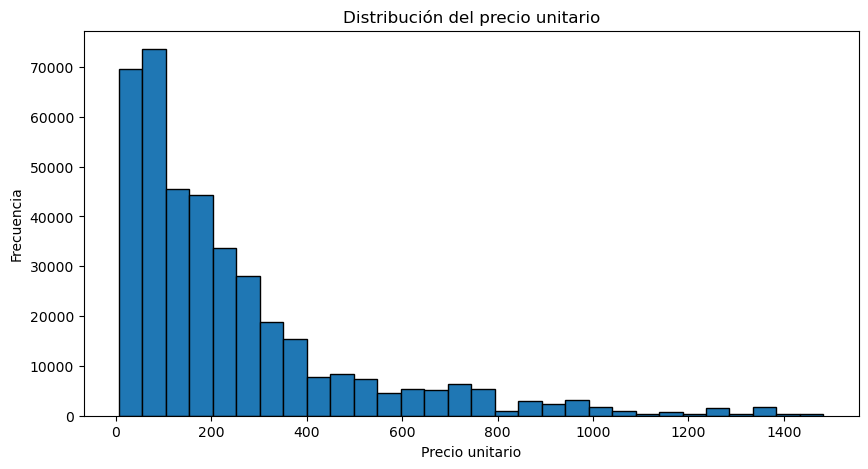

In [73]:
plt.figure(figsize=(10, 5))

plt.hist(pedidos["unit_price"], bins=30, edgecolor="black")

plt.title("Distribución del precio unitario")
plt.xlabel("Precio unitario")
plt.ylabel("Frecuencia")

plt.show()

En el caso de los pedidos vamos como la tendencia es hacia la derecha de nuevo, crearé tramos para ver como se distribuyen los pedidos y los porcentajes de distribución. 

In [74]:
bins = [0, 50, 100, 250, 500, 1000, float("inf")]
labels = ["0-50", "50-100", "100-250", "250-500", "500-1000", "+1000"]

pedidos["tramo_precio"] = pd.cut(
    pedidos["unit_price"],
    bins=bins,
    labels=labels,
    right=False
)

In [75]:
pedidos["tramo_precio"].value_counts().sort_index()

0-50         61112
50-100       73047
100-250     130711
250-500      81307
500-1000     42941
+1000         8451
Name: tramo_precio, dtype: int64

In [76]:
pedidos["tramo_precio"].value_counts(
    normalize=True
).sort_index() * 100

0-50        15.371420
50-100      18.373414
100-250     32.877563
250-500     20.451041
500-1000    10.800892
+1000        2.125669
Name: tramo_precio, dtype: float64

Estos datos confirman nuestro análisis anterior: las compras se concentran en productos de bajo-medio precio, mientras que los productos de precio más elevado tienen una frecuencia de compra considerablemente menor. Esta estructura explica la dispersión del precio unitario y el sesgo positivo en la dispersión.

In [77]:
pedidos.columns.to_list()

['order_id',
 'product_id',
 'quantity',
 'unit_price',
 'discount_percentage',
 'discount_amount',
 'gross_sales',
 'tax_amount',
 'shipping_cost',
 'net_sales',
 'product_cost',
 'profit',
 'tramo_precio']

In [78]:
pedidos.duplicated().sum()

0

In [79]:
pedidos[pedidos.duplicated(keep=False)]

,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit,tramo_precio


In [80]:
pedidos.isnull().sum()

order_id               0
product_id             0
quantity               0
unit_price             0
discount_percentage    0
discount_amount        0
gross_sales            0
tax_amount             0
shipping_cost          0
net_sales              0
product_cost           0
profit                 0
tramo_precio           0
dtype: int64

In [81]:
pedidos.dtypes

order_id                 object
product_id               object
quantity                  int64
unit_price              float64
discount_percentage     float64
discount_amount         float64
gross_sales             float64
tax_amount              float64
shipping_cost           float64
net_sales               float64
product_cost            float64
profit                  float64
tramo_precio           category
dtype: object

In [82]:
columnas_texto = [
    'order_id',
     'product_id'
]

for col in columnas_texto: 
    pedidos[col] = pedidos[col].astype("string")

In [83]:
pedidos.dtypes

order_id                 string
product_id               string
quantity                  int64
unit_price              float64
discount_percentage     float64
discount_amount         float64
gross_sales             float64
tax_amount              float64
shipping_cost           float64
net_sales               float64
product_cost            float64
profit                  float64
tramo_precio           category
dtype: object

In [84]:
pedidos = pedidos.rename(columns={
    "order_id": "id_pedido",
    "product_id": "id_producto",
    "quantity": "cantidad",
    "unit_price": "precio_unitario",
    "discount_percentage": "porcentaje_descuento",
    "discount_amount": "importe_descuento",
    "gross_sales": "ventas_brutas",
    "tax_amount": "importe_impuestos",
    "shipping_cost": "coste_envio",
    "net_sales": "ventas_netas",
    "product_cost": "coste_producto",
    "profit": "beneficio",
    "tramo_precio": "tramo_precio"
})


In [85]:
pedidos = pedidos.drop(columns=["tramo_precio"])

In [86]:
pedidos.columns.to_list()

['id_pedido',
 'id_producto',
 'cantidad',
 'precio_unitario',
 'porcentaje_descuento',
 'importe_descuento',
 'ventas_brutas',
 'importe_impuestos',
 'coste_envio',
 'ventas_netas',
 'coste_producto',
 'beneficio']

In [121]:
# ==============================
# COMPROBACIÓN FINAL - PEDIDOS
# ==============================

print("FORMA DEL DATASET")
print(pedidos.shape)

print("\nTIPOS DE DATOS")
print(pedidos.dtypes)

print("\nVALORES NULOS")
print(pedidos.isnull().sum())

print("\nDUPLICADOS COMPLETOS")
print(pedidos.duplicated().sum())

print("\nID_PEDIDO NULOS")
print(pedidos["id_pedido"].isnull().sum())

print("\nID_PRODUCTO NULOS")
print(pedidos["id_producto"].isnull().sum())

print("\nESTADÍSTICOS DESCRIPTIVOS")
print(
    pedidos[
        [
            "cantidad",
            "precio_unitario",
            "porcentaje_descuento",
            "importe_descuento",
            "ventas_brutas",
            "importe_impuestos",
            "coste_envio",
            "ventas_netas",
            "coste_producto",
            "beneficio"
        ]
    ].describe()
)

print("\nCANTIDADES <= 0")
print(
    (pedidos["cantidad"] <= 0).sum()
)

print("\nPRECIOS <= 0")
print(
    (pedidos["precio_unitario"] <= 0).sum()
)

print("\nDESCUENTOS NEGATIVOS")
print(
    (pedidos["porcentaje_descuento"] < 0).sum()
)

print("\nIMPORTES DE DESCUENTO NEGATIVOS")
print(
    (pedidos["importe_descuento"] < 0).sum()
)

print("\nVENTAS BRUTAS <= 0")
print(
    (pedidos["ventas_brutas"] <= 0).sum()
)

print("\nIMPUESTOS NEGATIVOS")
print(
    (pedidos["importe_impuestos"] < 0).sum()
)

print("\nCOSTES DE ENVÍO NEGATIVOS")
print(
    (pedidos["coste_envio"] < 0).sum()
)

print("\nVENTAS NETAS <= 0")
print(
    (pedidos["ventas_netas"] <= 0).sum()
)

print("\nCOSTES DE PRODUCTO NEGATIVOS")
print(
    (pedidos["coste_producto"] < 0).sum()
)

print("\nPRIMERAS FILAS")
display(pedidos.head())

FORMA DEL DATASET
(397569, 12)

TIPOS DE DATOS
id_pedido                string
id_producto              string
cantidad                  int64
precio_unitario         float64
porcentaje_descuento    float64
importe_descuento       float64
ventas_brutas           float64
importe_impuestos       float64
coste_envio             float64
ventas_netas            float64
coste_producto          float64
beneficio               float64
dtype: object

VALORES NULOS
id_pedido               0
id_producto             0
cantidad                0
precio_unitario         0
porcentaje_descuento    0
importe_descuento       0
ventas_brutas           0
importe_impuestos       0
coste_envio             0
ventas_netas            0
coste_producto          0
beneficio               0
dtype: int64

DUPLICADOS COMPLETOS
0

ID_PEDIDO NULOS
0

ID_PRODUCTO NULOS
0

ESTADÍSTICOS DESCRIPTIVOS
            cantidad  precio_unitario  porcentaje_descuento  \
count  397569.000000    397569.000000         397569.000000  

,id_pedido,id_producto,cantidad,precio_unitario,porcentaje_descuento,importe_descuento,ventas_brutas,importe_impuestos,coste_envio,ventas_netas,coste_producto,beneficio
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84
3,ORD-773460,PROD-000268,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37
4,ORD-449374,PROD-001040,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53


### Tabla ventas

In [88]:
ventas.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [89]:
ventas.shape
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  object 
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  object 
 4   sales_channel             138116 non-null  object 
 5   customer_id               138116 non-null  object 
 6   customer_name             138116 non-null  object 
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  object 
 9   customer_segment          138116 non-null  object 
 10  customer_type             138116 non-null  object 
 11  customer_city             138116 non-null  object 
 12  customer_state            138116 non-null  object 
 13  customer_country          138116 non-null  o

In [90]:
ventas.describe()

,customer_age,customer_postal_code,delivery_days,estimated_delivery_days,customer_rating,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,customer_order_count
count,138116.000000,138116.000000,113559.000000,113559.000000,113559.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000,138116.000000
mean,45.862681,50210.889310,4.557772,4.298875,3.677015,103.991051,51.934128,5.615244,1375.384176,237.621614,122.462933,22.278080,1282.503575,708.903449,551.322046,45.065997,8971.639047,6.990559
std,16.467676,28569.767779,2.810012,2.594080,0.483672,115.175640,73.217692,3.371289,1291.009554,378.779459,140.939368,16.022739,1169.274669,730.044970,516.300936,13.120357,4430.506588,2.444166
min,18.000000,516.000000,0.000000,0.000000,1.600000,0.000000,0.000000,1.000000,6.310000,0.000000,0.340000,0.000000,5.800000,1.970000,-1281.590000,-59.550000,22.550000,1.000000
25%,32.000000,25509.000000,2.000000,2.000000,3.400000,17.000000,3.000000,3.000000,458.920000,26.327500,34.650000,9.820000,448.200000,207.667500,190.757500,38.880000,5713.570000,5.000000
50%,46.000000,50183.000000,4.000000,4.000000,3.700000,70.000000,25.000000,5.000000,995.730000,103.285000,77.010000,19.190000,950.760000,478.955000,408.395000,46.990000,8392.525000,7.000000
75%,60.000000,74898.000000,7.000000,6.000000,4.000000,151.000000,71.000000,8.000000,1871.200000,277.125000,156.200000,30.750000,1744.582500,953.762500,752.845000,53.770000,11651.030000,9.000000
max,74.000000,99950.000000,14.000000,10.000000,5.000000,1621.000000,1063.000000,24.000000,16051.190000,6759.020000,2091.520000,149.520000,16218.000000,9963.410000,7083.680000,77.590000,30268.440000,20.000000


In [95]:
ventas.columns.to_list()

['order_id',
 'order_date',
 'order_time',
 'order_status',
 'sales_channel',
 'customer_id',
 'customer_name',
 'customer_age',
 'gender',
 'customer_segment',
 'customer_type',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'customer_postal_code',
 'payment_method',
 'payment_status',
 'currency',
 'shipping_method',
 'warehouse',
 'delivery_days',
 'estimated_delivery_days',
 'delivery_status',
 'return_status',
 'return_reason',
 'customer_rating',
 'review_sentiment',
 'customer_review',
 'marketing_channel',
 'campaign_name',
 'coupon_code',
 'loyalty_points_earned',
 'loyalty_points_redeemed',
 'quantity',
 'gross_sales',
 'discount_amount',
 'tax_amount',
 'shipping_cost',
 'net_sales',
 'product_cost',
 'profit',
 'profit_margin_percentage',
 'customer_lifetime_value',
 'is_repeat_customer',
 'customer_order_count']

In [96]:
ventas = ventas.rename(columns={
    "order_id": "id_pedido",
    "order_date": "fecha_pedido",
    "order_time": "hora_pedido",
    "order_status": "estado_pedido",
    "sales_channel": "canal_venta",
    "customer_id": "id_cliente",
    "customer_name": "nombre_cliente",
    "customer_age": "edad_cliente",
    "gender": "genero",
    "customer_segment": "segmento_cliente",
    "customer_type": "tipo_cliente",
    "customer_city": "ciudad_cliente",
    "customer_state": "provincia_cliente",
    "customer_country": "pais_cliente",
    "region": "region",
    "customer_postal_code": "codigo_postal_cliente",
    "payment_method": "metodo_pago",
    "payment_status": "estado_pago",
    "currency": "moneda",
    "shipping_method": "metodo_envio",
    "warehouse": "almacen",
    "delivery_days": "dias_entrega",
    "estimated_delivery_days": "dias_entrega_estimados",
    "delivery_status": "estado_entrega",
    "return_status": "estado_devolucion",
    "return_reason": "motivo_devolucion",
    "customer_rating": "valoracion_cliente",
    "review_sentiment": "sentimiento_resena",
    "customer_review": "resena_cliente",
    "marketing_channel": "canal_marketing",
    "campaign_name": "nombre_campana",
    "coupon_code": "codigo_cupon",
    "loyalty_points_earned": "puntos_fidelizacion_obtenidos",
    "loyalty_points_redeemed": "puntos_fidelizacion_canjeados",
    "quantity": "cantidad",
    "gross_sales": "ventas_brutas",
    "discount_amount": "importe_descuento",
    "tax_amount": "importe_impuestos",
    "shipping_cost": "coste_envio",
    "net_sales": "ventas_netas",
    "product_cost": "coste_producto",
    "profit": "beneficio",
    "profit_margin_percentage": "porcentaje_margen_beneficio",
    "customer_lifetime_value": "valor_vida_cliente",
    "is_repeat_customer": "cliente_recurrente",
    "customer_order_count": "numero_pedidos_cliente"
})

In [97]:
ventas.columns.to_list()

['id_pedido',
 'fecha_pedido',
 'hora_pedido',
 'estado_pedido',
 'canal_venta',
 'id_cliente',
 'nombre_cliente',
 'edad_cliente',
 'genero',
 'segmento_cliente',
 'tipo_cliente',
 'ciudad_cliente',
 'provincia_cliente',
 'pais_cliente',
 'region',
 'codigo_postal_cliente',
 'metodo_pago',
 'estado_pago',
 'moneda',
 'metodo_envio',
 'almacen',
 'dias_entrega',
 'dias_entrega_estimados',
 'estado_entrega',
 'estado_devolucion',
 'motivo_devolucion',
 'valoracion_cliente',
 'sentimiento_resena',
 'resena_cliente',
 'canal_marketing',
 'nombre_campana',
 'codigo_cupon',
 'puntos_fidelizacion_obtenidos',
 'puntos_fidelizacion_canjeados',
 'cantidad',
 'ventas_brutas',
 'importe_descuento',
 'importe_impuestos',
 'coste_envio',
 'ventas_netas',
 'coste_producto',
 'beneficio',
 'porcentaje_margen_beneficio',
 'valor_vida_cliente',
 'cliente_recurrente',
 'numero_pedidos_cliente']

In [92]:
ventas.duplicated().sum()

0

In [98]:
ventas.isnull().sum()

id_pedido                             0
fecha_pedido                          0
hora_pedido                           0
estado_pedido                         0
canal_venta                           0
id_cliente                            0
nombre_cliente                        0
edad_cliente                          0
genero                                0
segmento_cliente                      0
tipo_cliente                          0
ciudad_cliente                        0
provincia_cliente                     0
pais_cliente                          0
region                                0
codigo_postal_cliente                 0
metodo_pago                           0
estado_pago                           0
moneda                                0
metodo_envio                          0
almacen                               0
dias_entrega                      24557
dias_entrega_estimados            24557
estado_entrega                        0
estado_devolucion                128654


Podemos ver múltiples nulos, vamos a comprobar la interrelación que pueda existir entre "dias_entrega", "dias_entrega_estimados" y "valoracion_cliente".

In [100]:
ventas[
    ["dias_entrega", "dias_entrega_estimados", "valoracion_cliente"]
].isnull().sum()

dias_entrega              24557
dias_entrega_estimados    24557
valoracion_cliente        24557
dtype: int64

Vemos que tienen exactamente el mismo número de nulos, ahora profundizamos y veremos el contenido de esas filas. 

In [104]:
nulos_mismas_filas = (
    ventas["dias_entrega"].isna()
    & ventas["dias_entrega_estimados"].isna()
    & ventas["valoracion_cliente"].isna()
)

print(nulos_mismas_filas.sum())

24557


In [106]:
ventas.loc[
    nulos_mismas_filas,
    [
        "estado_pedido",
        "estado_entrega",
        "estado_pago",
        "estado_devolucion"
    ]
].value_counts(dropna=False)

estado_pedido  estado_entrega  estado_pago  estado_devolucion
Returned       Cancelled       Refunded     Returned             9462
Cancelled      Cancelled       Failed       NaN                  8398
Pending        Cancelled       Pending      NaN                  2669
                               Failed       NaN                  2031
                               Paid         NaN                  1997
dtype: int64

In [107]:
print("Nulos dias_entrega:", ventas["dias_entrega"].isna().sum())
print("Nulos dias_entrega_estimados:", ventas["dias_entrega_estimados"].isna().sum())
print("Nulos valoracion_cliente:", ventas["valoracion_cliente"].isna().sum())

print("\nEstados asociados a los nulos:")
print(
    ventas.loc[
        ventas["dias_entrega"].isna(),
        ["estado_pedido", "estado_entrega", "estado_pago", "estado_devolucion"]
    ].value_counts(dropna=False)
)

Nulos dias_entrega: 24557
Nulos dias_entrega_estimados: 24557
Nulos valoracion_cliente: 24557

Estados asociados a los nulos:
estado_pedido  estado_entrega  estado_pago  estado_devolucion
Returned       Cancelled       Refunded     Returned             9462
Cancelled      Cancelled       Failed       NaN                  8398
Pending        Cancelled       Pending      NaN                  2669
                               Failed       NaN                  2031
                               Paid         NaN                  1997
dtype: int64


Los 24.557 valores nulos detectados en las variables relacionadas con entrega y valoración corresponden íntegramente a pedidos devueltos, cancelados o pendientes. Se consideran ausencias estructurales derivadas del estado de la operación y se mantienen como valores nulos.

In [108]:
ventas.dtypes

id_pedido                         object
fecha_pedido                      object
hora_pedido                       object
estado_pedido                     object
canal_venta                       object
id_cliente                        object
nombre_cliente                    object
edad_cliente                       int64
genero                            object
segmento_cliente                  object
tipo_cliente                      object
ciudad_cliente                    object
provincia_cliente                 object
pais_cliente                      object
region                            object
codigo_postal_cliente              int64
metodo_pago                       object
estado_pago                       object
moneda                            object
metodo_envio                      object
almacen                           object
dias_entrega                     float64
dias_entrega_estimados           float64
estado_entrega                    object
estado_devolucio

In [109]:
columnas_texto = [
    'id_pedido',
    'estado_pedido',
    'canal_venta',
    'id_cliente',
    'nombre_cliente',
    'genero',
    'segmento_cliente',
    'tipo_cliente',
    'ciudad_cliente',
    'provincia_cliente',
    'pais_cliente',
    'region',
    'metodo_pago',
    'estado_pago',
    'moneda',
    'metodo_envio',
    'almacen',
    'estado_entrega',
    'estado_devolucion',
    'motivo_devolucion',
    'sentimiento_resena',
    'resena_cliente',
    'canal_marketing',
    'nombre_campana',
    'codigo_cupon'
]

for col in columnas_texto:
    ventas[col] = ventas[col].astype("string")

In [113]:
ventas["fecha_pedido"]= pd.to_datetime(ventas["fecha_pedido"])

In [116]:
print(ventas["fecha_pedido"].dtype)

datetime64[ns]


In [123]:
ventas[
    (ventas["beneficio"] < 0) &
    (ventas["porcentaje_margen_beneficio"] >= 0)
][
    [
        "id_pedido",
        "ventas_netas",
        "coste_producto",
        "beneficio",
        "porcentaje_margen_beneficio"
    ]
]

,id_pedido,ventas_netas,coste_producto,beneficio,porcentaje_margen_beneficio
137309,ORD-272434,214.13,214.02,-0.01,-0.0


In [122]:
# ==============================
# COMPROBACIÓN FINAL - VENTAS
# ==============================

print("FORMA DEL DATASET")
print(ventas.shape)

print("\nTIPOS DE DATOS")
print(ventas.dtypes)

print("\nVALORES NULOS")
print(ventas.isnull().sum())

print("\nDUPLICADOS COMPLETOS")
print(ventas.duplicated().sum())

print("\nID_PEDIDO NULOS")
print(ventas["id_pedido"].isnull().sum())

print("\nID_CLIENTE NULOS")
print(ventas["id_cliente"].isnull().sum())

print("\nESTADÍSTICOS DESCRIPTIVOS")
print(
    ventas[
        [
            "edad_cliente",
            "dias_entrega",
            "dias_entrega_estimados",
            "valoracion_cliente",
            "puntos_fidelizacion_obtenidos",
            "puntos_fidelizacion_canjeados",
            "cantidad",
            "ventas_brutas",
            "importe_descuento",
            "importe_impuestos",
            "coste_envio",
            "ventas_netas",
            "coste_producto",
            "beneficio",
            "porcentaje_margen_beneficio",
            "valor_vida_cliente",
            "numero_pedidos_cliente"
        ]
    ].describe()
)

print("\nEDADES FUERA DE RANGO 18-100")
print(
    (
        (ventas["edad_cliente"] < 18) |
        (ventas["edad_cliente"] > 100)
    ).sum()
)

print("\nVALORACIONES FUERA DE RANGO 0-5")
print(
    (
        (ventas["valoracion_cliente"] < 0) |
        (ventas["valoracion_cliente"] > 5)
    ).sum()
)

print("\nCANTIDADES <= 0")
print(
    (ventas["cantidad"] <= 0).sum()
)

print("\nDÍAS DE ENTREGA NEGATIVOS")
print(
    (ventas["dias_entrega"] < 0).sum()
)

print("\nDÍAS DE ENTREGA ESTIMADOS NEGATIVOS")
print(
    (ventas["dias_entrega_estimados"] < 0).sum()
)

print("\nVENTAS BRUTAS <= 0")
print(
    (ventas["ventas_brutas"] <= 0).sum()
)

print("\nIMPORTES DE DESCUENTO NEGATIVOS")
print(
    (ventas["importe_descuento"] < 0).sum()
)

print("\nIMPUESTOS NEGATIVOS")
print(
    (ventas["importe_impuestos"] < 0).sum()
)

print("\nCOSTES DE ENVÍO NEGATIVOS")
print(
    (ventas["coste_envio"] < 0).sum()
)

print("\nVENTAS NETAS <= 0")
print(
    (ventas["ventas_netas"] <= 0).sum()
)

print("\nCOSTES DE PRODUCTO NEGATIVOS")
print(
    (ventas["coste_producto"] < 0).sum()
)

print("\nVALOR DE VIDA DEL CLIENTE NEGATIVO")
print(
    (ventas["valor_vida_cliente"] < 0).sum()
)

print("\nNÚMERO DE PEDIDOS NEGATIVO")
print(
    (ventas["numero_pedidos_cliente"] < 0).sum()
)

print("\nNULOS EN ENTREGA Y VALORACIÓN")
nulos_mismas_filas = (
    ventas["dias_entrega"].isna()
    & ventas["dias_entrega_estimados"].isna()
    & ventas["valoracion_cliente"].isna()
)

print(nulos_mismas_filas.sum())

print("\nESTADOS ASOCIADOS A ESOS NULOS")
print(
    ventas.loc[
        nulos_mismas_filas,
        [
            "estado_pedido",
            "estado_entrega",
            "estado_pago",
            "estado_devolucion"
        ]
    ].value_counts(dropna=False)
)

print("\nFECHA MÍNIMA Y MÁXIMA")
print("Mínima:", ventas["fecha_pedido"].min())
print("Máxima:", ventas["fecha_pedido"].max())

print("\nPRIMERAS FILAS")
display(ventas.head())

FORMA DEL DATASET
(138116, 46)

TIPOS DE DATOS
id_pedido                                string
fecha_pedido                     datetime64[ns]
hora_pedido                              object
estado_pedido                            string
canal_venta                              string
id_cliente                               string
nombre_cliente                           string
edad_cliente                              int64
genero                                   string
segmento_cliente                         string
tipo_cliente                             string
ciudad_cliente                           string
provincia_cliente                        string
pais_cliente                             string
region                                   string
codigo_postal_cliente                     int64
metodo_pago                              string
estado_pago                              string
moneda                                   string
metodo_envio                             

,id_pedido,fecha_pedido,hora_pedido,estado_pedido,canal_venta,id_cliente,nombre_cliente,edad_cliente,genero,segmento_cliente,...,importe_descuento,importe_impuestos,coste_envio,ventas_netas,coste_producto,beneficio,porcentaje_margen_beneficio,valor_vida_cliente,cliente_recurrente,numero_pedidos_cliente
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


### Exportamos los datos limpios 

In [127]:
from pathlib import Path
ruta_salida = Path (r"C:\Users\Samuel\Desktop\Proyectos\E-Commerce Sales Analytics Dataset\Data"
)

clientes.to_csv(ruta_salida / "clientes_limpio.csv" , index = False,encoding="utf-8-sig" )
productos.to_csv(ruta_salida / "productos_limpio.csv", index=False, encoding="utf-8-sig")
pedidos.to_csv(ruta_salida / "pedidos_limpio.csv", index=False, encoding="utf-8-sig")
ventas.to_csv(ruta_salida / "ventas_limpio.csv", index=False, encoding="utf-8-sig")

print("Archivos exportados correctamente")

Archivos exportados correctamente
